In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/hull-tactical-market-prediction/train.csv
/kaggle/input/hull-tactical-market-prediction/test.csv
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/default_inference_server.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/default_gateway.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/__init__.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/templates.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/base_gateway.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/relay.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/kaggle_evaluation.proto
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/__init__.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/generated/kaggle_evaluation_pb2.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/generated/kaggle_evaluation_pb2_grpc.py
/kaggl

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from scipy.optimize import minimize_scalar  # For tuning
from scipy.optimize import fmin_l_bfgs_b  # For GARCH optimization
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random

# Constants from adjusted_sharpe
EPS = 1e-9
ANNUAL_DAYS = 252
MAX_POSITION = 1.0  # Assuming from context
MIN_POSITION = -1.0

# Step 1: Load the data
df_train = pd.read_csv('/kaggle/input/hull-tactical-market-prediction/train.csv')
df_test = pd.read_csv('/kaggle/input/hull-tactical-market-prediction/test.csv')

# Combine for common processing if needed, but handle separately
df = df_train.copy()  # Focus on train
df_train.shape

(9021, 98)

In [3]:
# Step 2: Handle Null Values
null_counts = df.isnull().sum()
print("Null Counts:\n", null_counts[null_counts > 0])
df = df.dropna()
print(f"Shape after dropping nulls: {df.shape}")

test_nulls = df_test.isnull().sum()
print("Test Null Counts:\n", test_nulls[test_nulls > 0])
df_test = df_test.dropna()

Null Counts:
 E1     1784
E10    1006
E11    1006
E12    1006
E13    1006
       ... 
V5     1512
V6     1006
V7     1511
V8     1006
V9     4539
Length: 85, dtype: int64
Shape after dropping nulls: (2052, 98)
Test Null Counts:
 Series([], dtype: int64)


In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9021 entries, 0 to 9020
Data columns (total 98 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   date_id                        9021 non-null   int64  
 1   D1                             9021 non-null   int64  
 2   D2                             9021 non-null   int64  
 3   D3                             9021 non-null   int64  
 4   D4                             9021 non-null   int64  
 5   D5                             9021 non-null   int64  
 6   D6                             9021 non-null   int64  
 7   D7                             9021 non-null   int64  
 8   D8                             9021 non-null   int64  
 9   D9                             9021 non-null   int64  
 10  E1                             7237 non-null   float64
 11  E10                            8015 non-null   float64
 12  E11                            8015 non-null   f

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

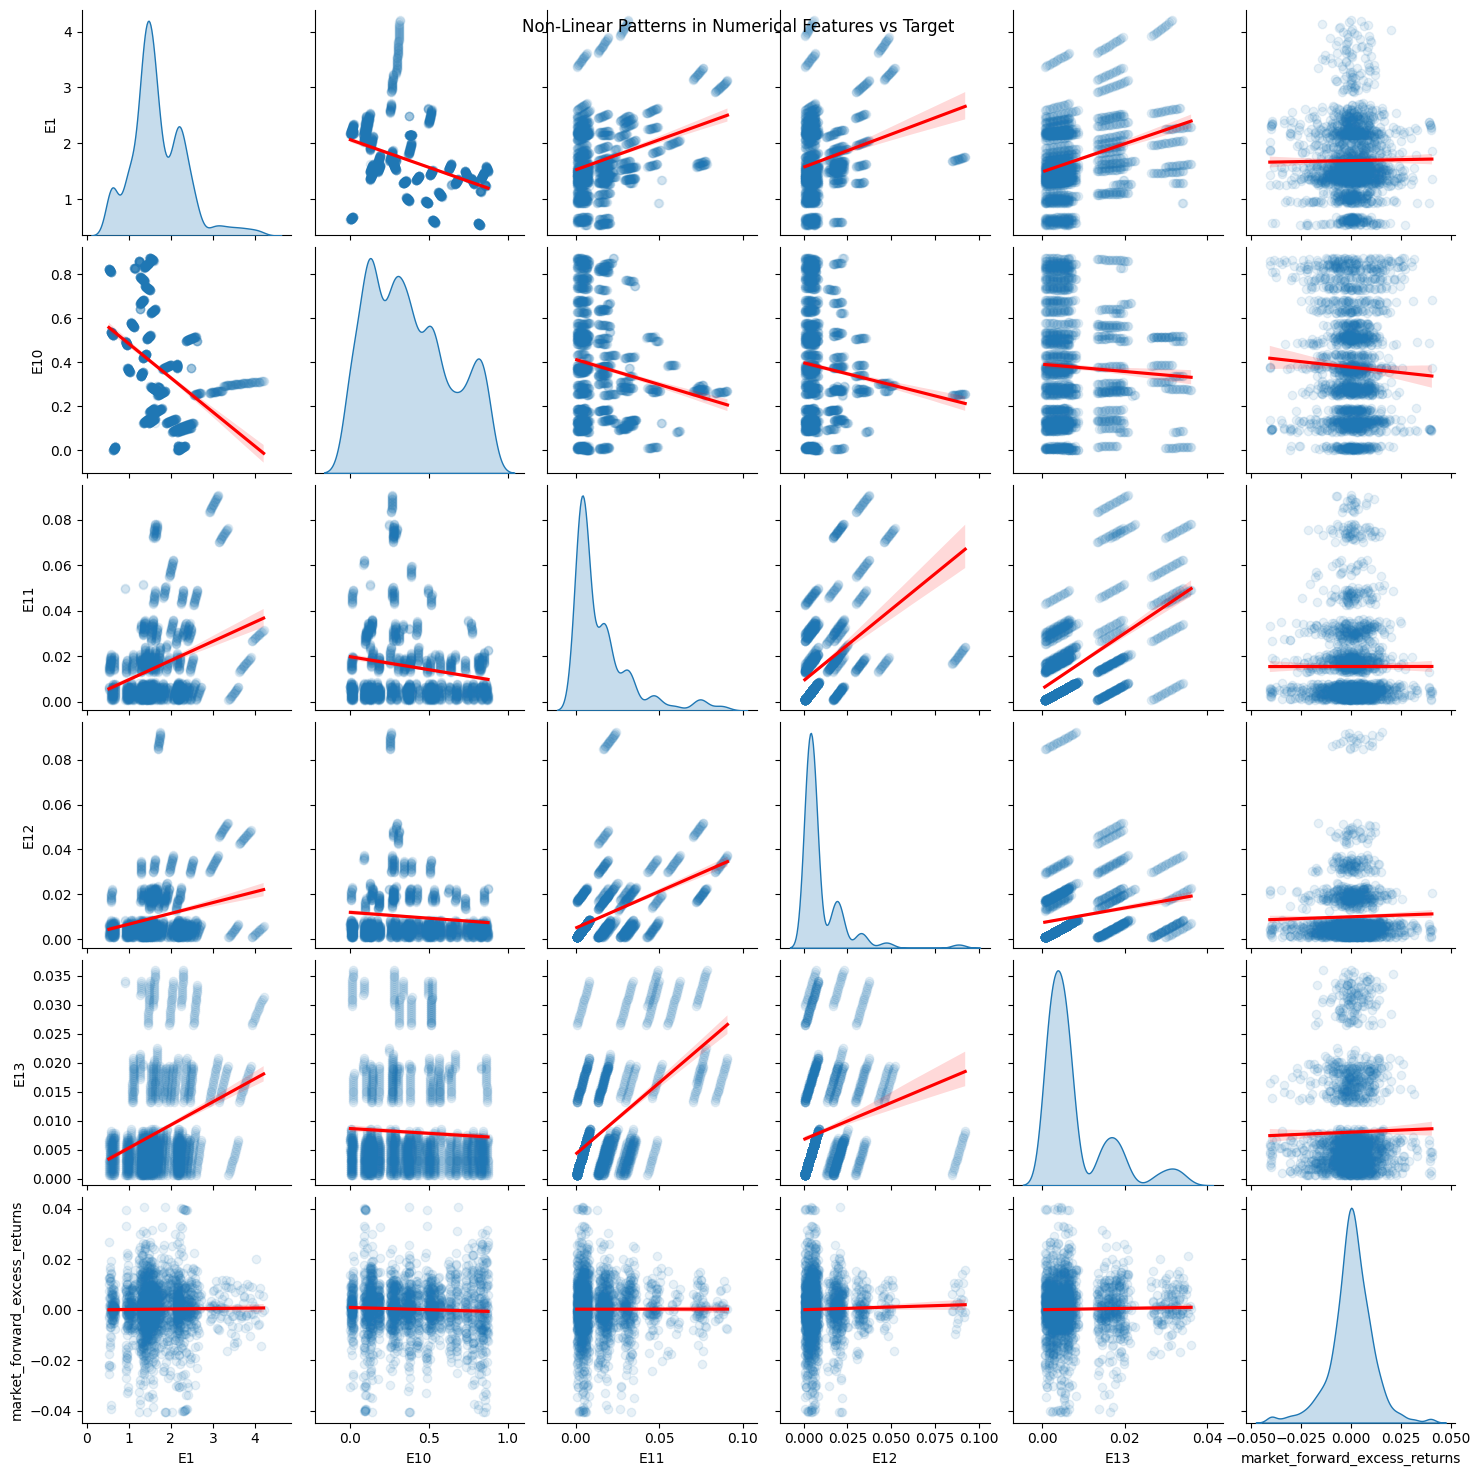

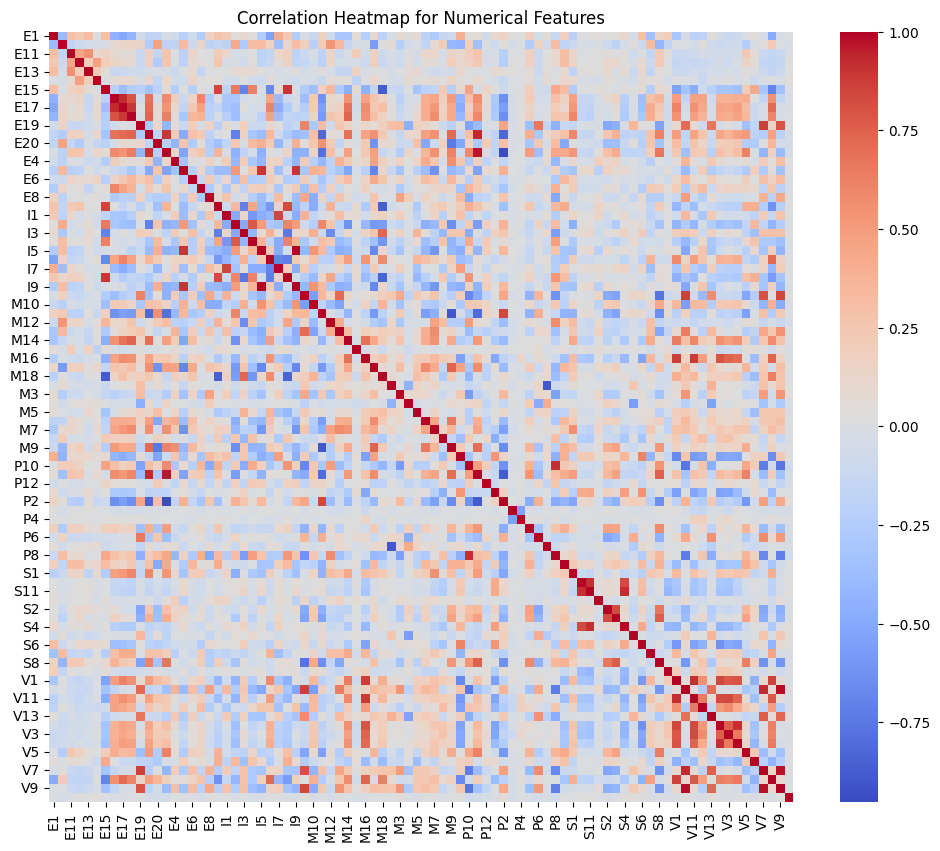

Chi-Squared Tests:
    Cat1 Cat2         Chi2        p-value
0    D1   D2  2019.038745   0.000000e+00
1    D1   D3     0.000000   1.000000e+00
2    D1   D4     0.299227   5.843677e-01
3    D1   D5     0.539605   4.625963e-01
4    D1   D6     0.272565   6.016166e-01
5    D1   D7     2.215833   1.366013e-01
6    D1   D8     2.463925   1.164874e-01
7    D1   D9     0.936395   3.332068e-01
8    D2   D3     0.000000   1.000000e+00
9    D2   D4     0.299227   5.843677e-01
10   D2   D5     0.539605   4.625963e-01
11   D2   D6     0.272565   6.016166e-01
12   D2   D7     2.215833   1.366013e-01
13   D2   D8     2.463925   1.164874e-01
14   D2   D9     0.936395   3.332068e-01
15   D3   D4     0.000000   1.000000e+00
16   D3   D5    23.022024   1.601561e-06
17   D3   D6    30.834044   2.810636e-08
18   D3   D7     3.955419   4.672069e-02
19   D3   D8    16.007097   6.310547e-05
20   D3   D9    16.007097   6.310547e-05
21   D4   D5     0.007334   9.317557e-01
22   D4   D6     0.235335   6.275961e

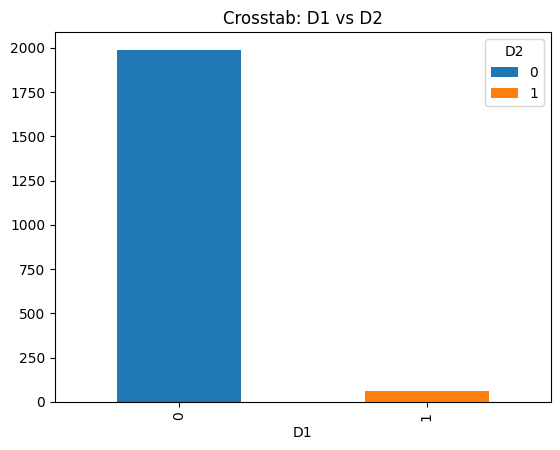

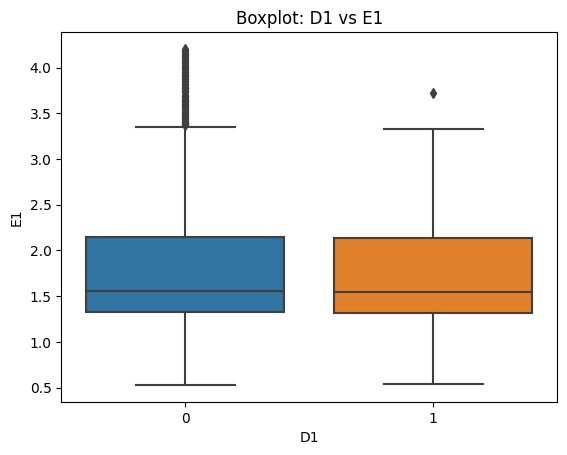

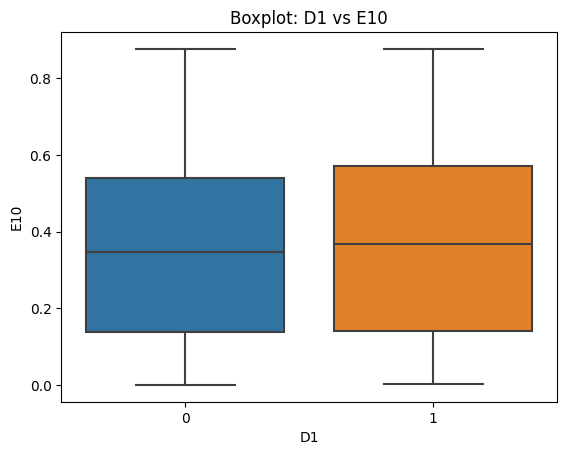

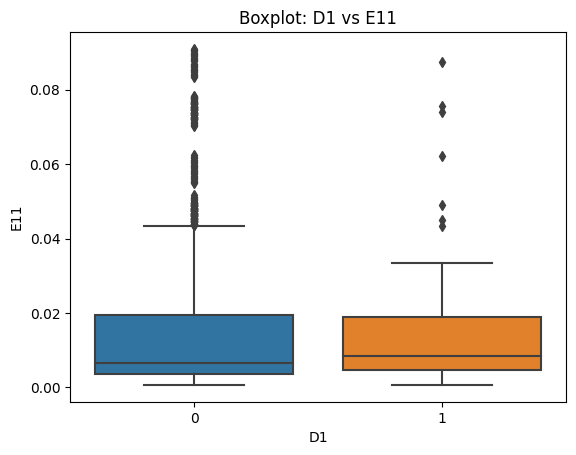

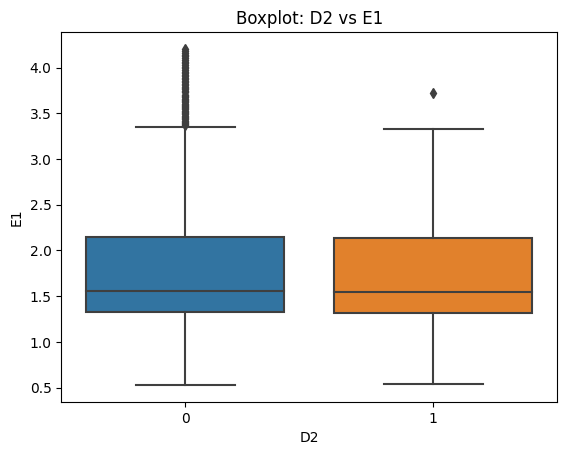

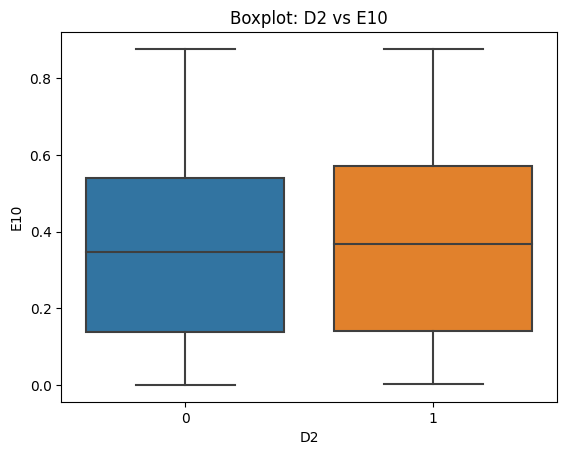

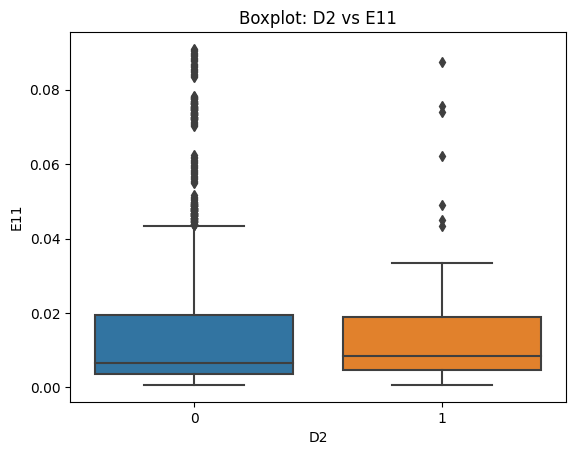

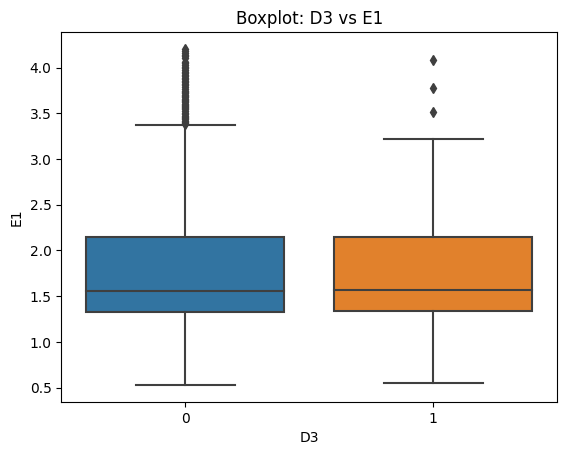

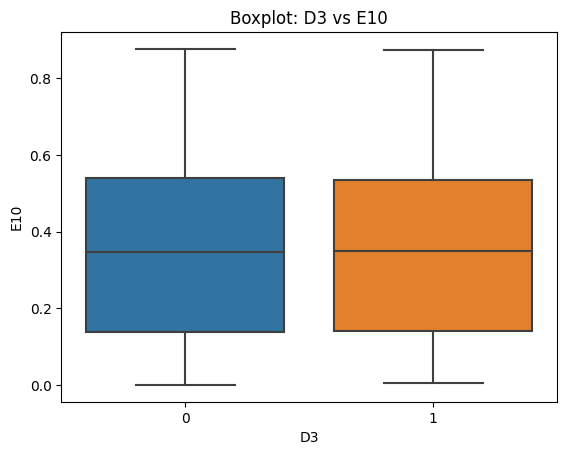

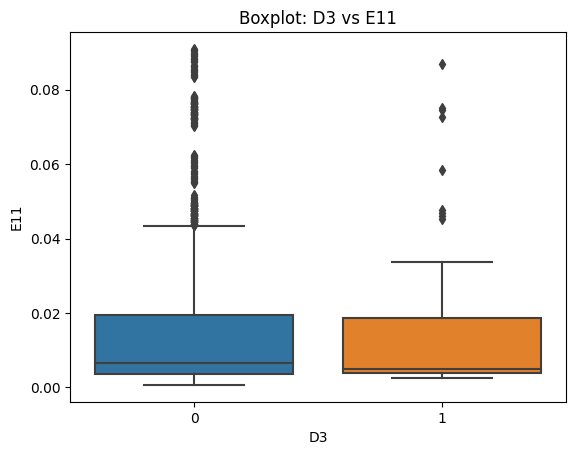

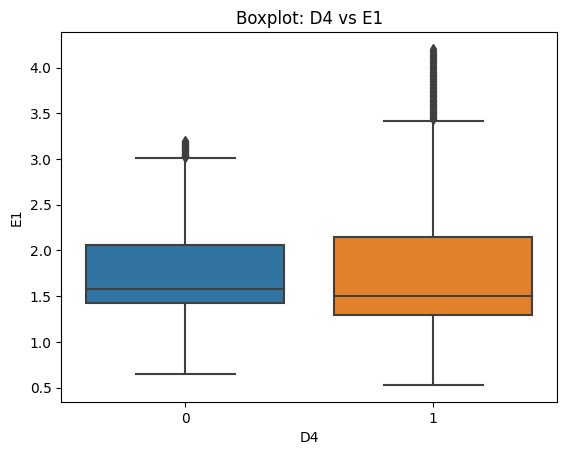

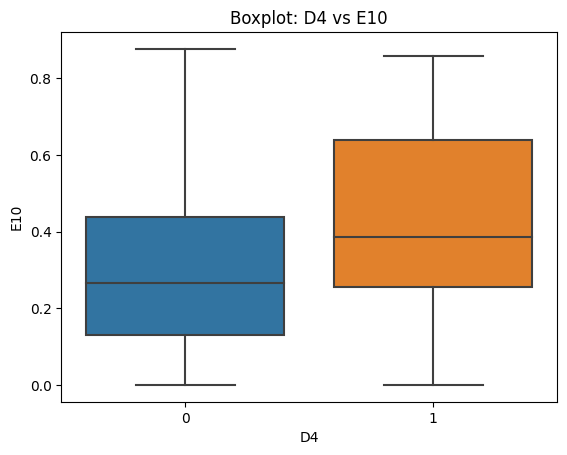

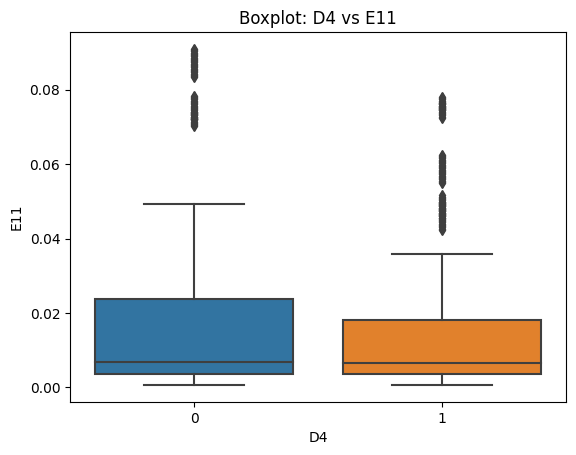

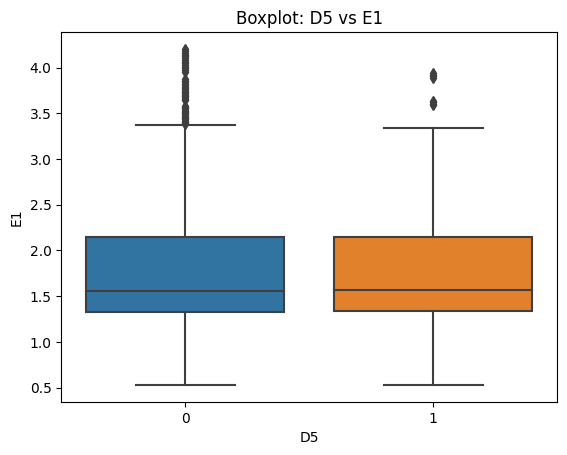

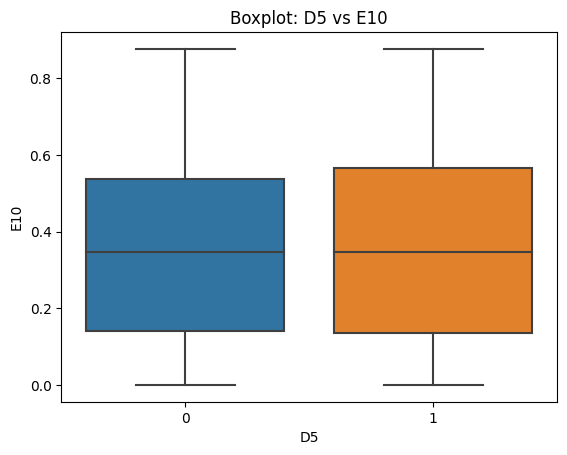

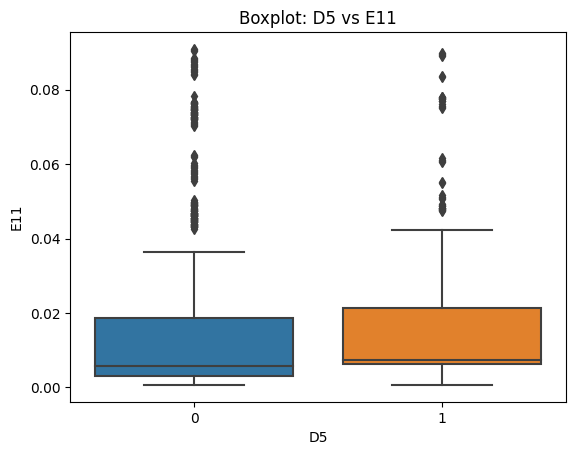

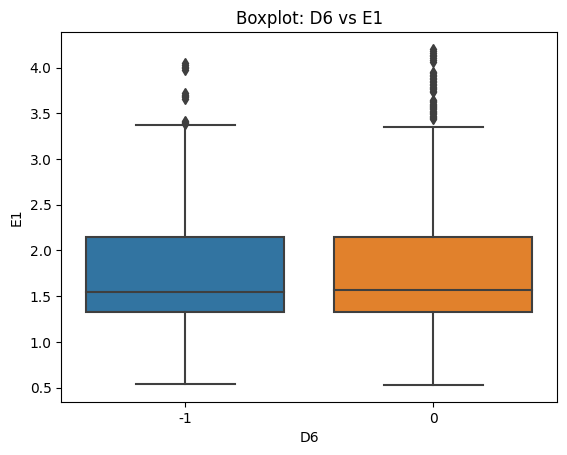

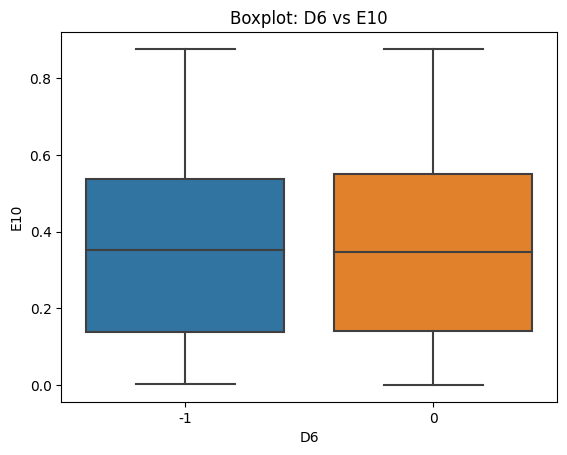

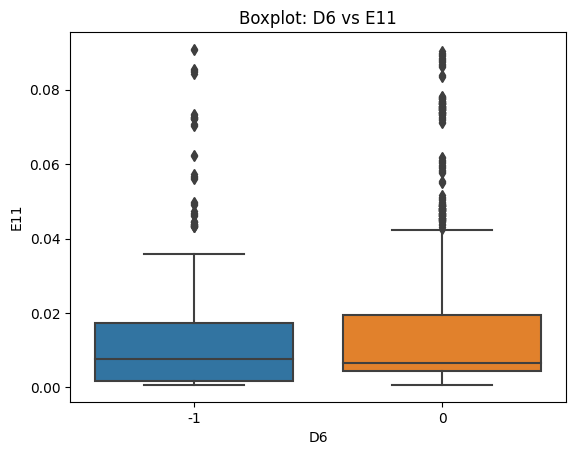

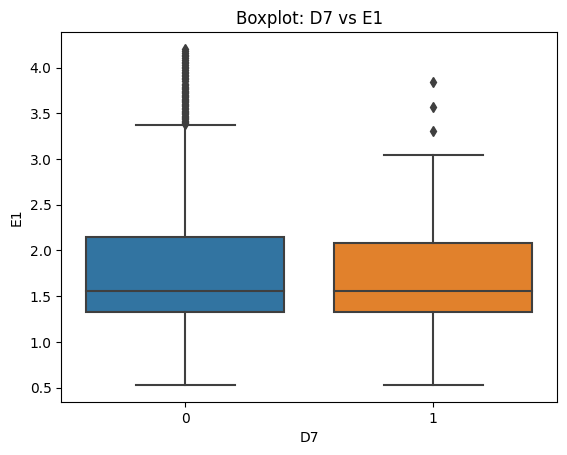

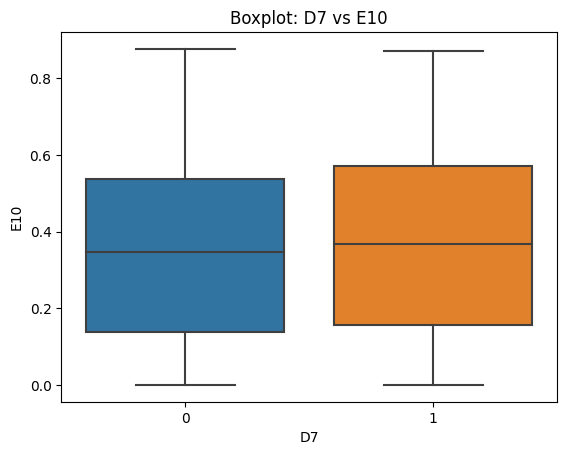

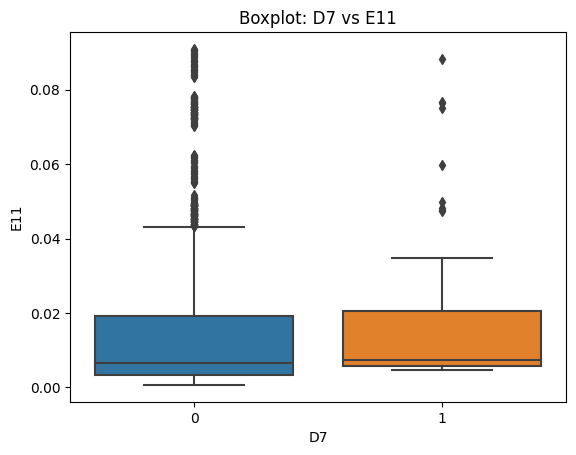

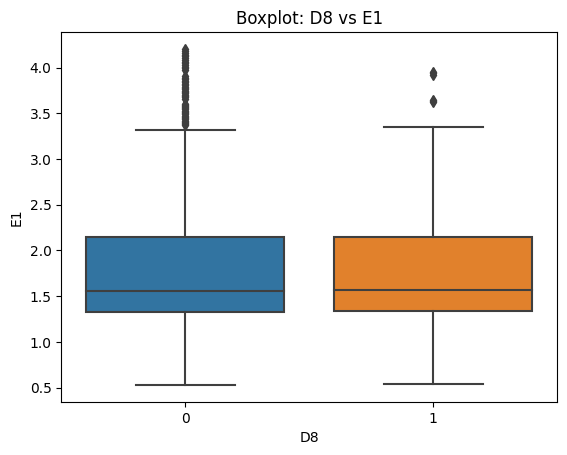

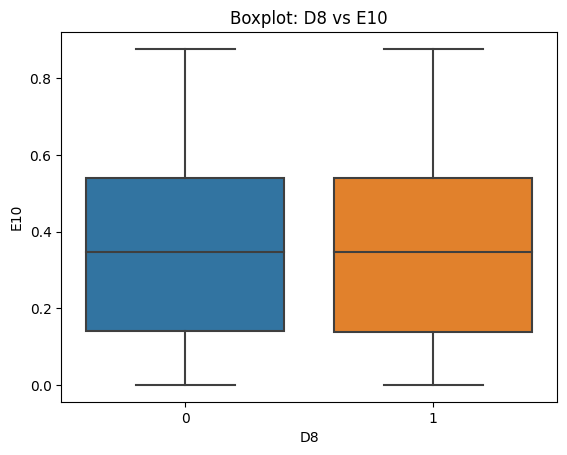

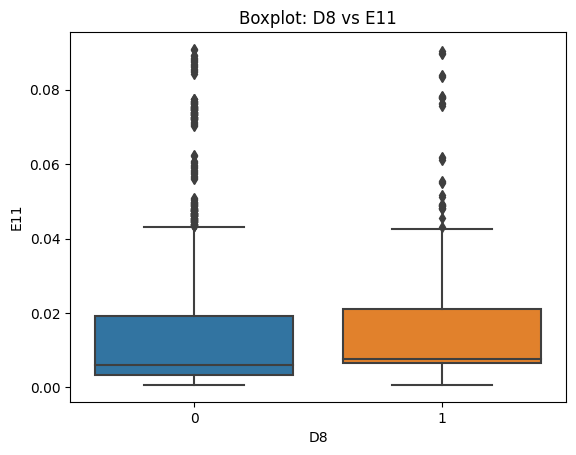

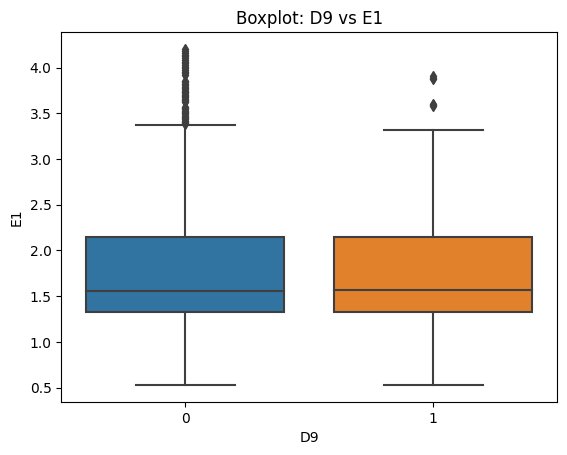

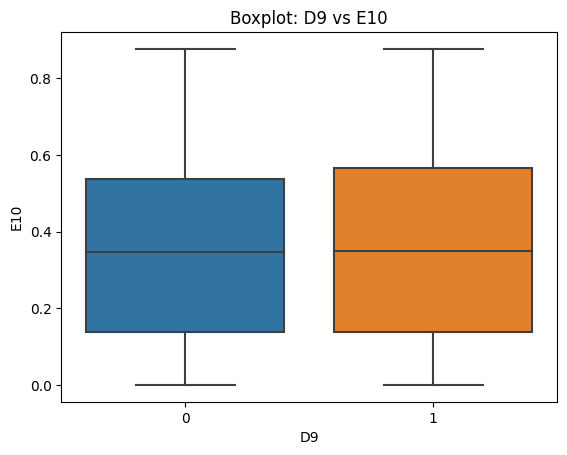

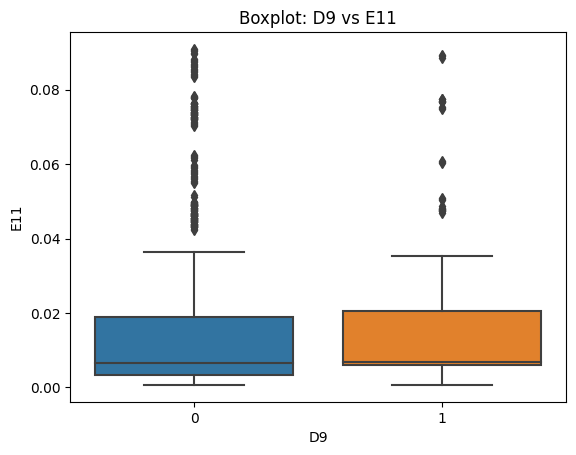

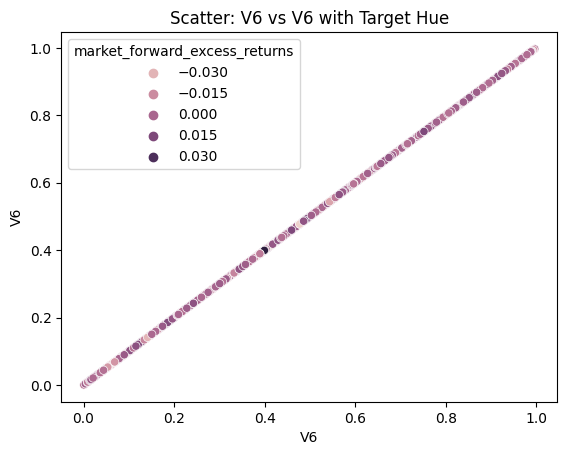

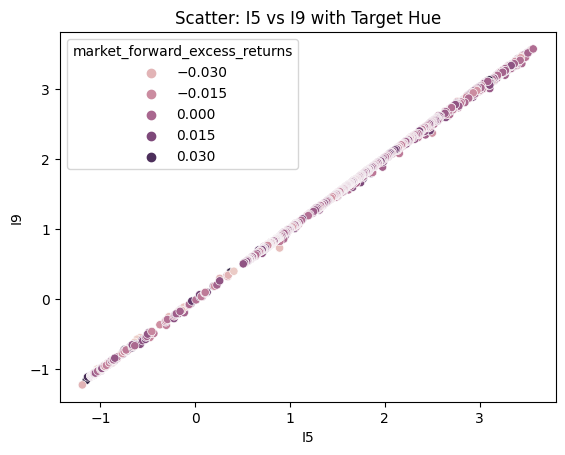

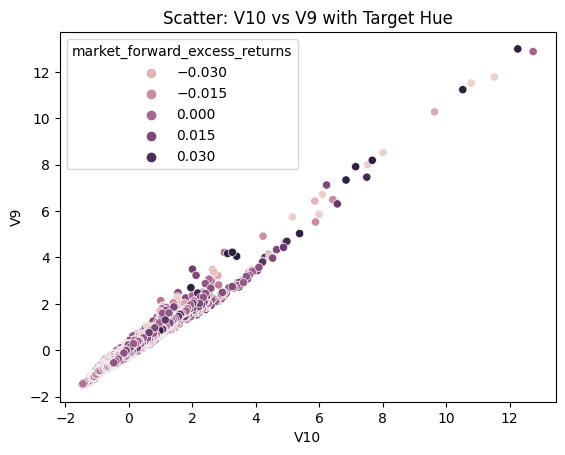

In [5]:
# Step 3: EDA (as before)
cat_cols = [col for col in df.columns if col.startswith('D') and col != 'date_id']
num_cols = [col for col in df.columns if col not in cat_cols + ['date_id', 'forward_returns', 'risk_free_rate', 'market_forward_excess_returns']]
target = 'market_forward_excess_returns'

sns.pairplot(df[num_cols[:5] + [target]], kind='reg', diag_kind='kde', plot_kws={'line_kws':{'color':'red'}, 'scatter_kws': {'alpha': 0.1}})
plt.suptitle('Non-Linear Patterns in Numerical Features vs Target')
plt.show()

mi_scores = []  # Placeholder, since no sklearn; use corr for approx non-linear via abs
corr_matrix = df[num_cols + [target]].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap for Numerical Features')
plt.show()

chi2_results = []
for i in range(len(cat_cols)):
    for j in range(i+1, len(cat_cols)):
        chi2, p, _, _ = chi2_contingency(pd.crosstab(df[cat_cols[i]], df[cat_cols[j]]))
        chi2_results.append((cat_cols[i], cat_cols[j], chi2, p))
chi2_df = pd.DataFrame(chi2_results, columns=['Cat1', 'Cat2', 'Chi2', 'p-value'])
print("Chi-Squared Tests:\n", chi2_df)

if len(cat_cols) >= 2:
    pd.crosstab(df[cat_cols[0]], df[cat_cols[1]]).plot(kind='bar', stacked=True)
    plt.title(f'Crosstab: {cat_cols[0]} vs {cat_cols[1]}')
    plt.show()

for cat in cat_cols:
    for num in num_cols[:3]:
        sns.boxplot(x=df[cat], y=df[num])
        plt.title(f'Boxplot: {cat} vs {num}')
        plt.show()

top_corr_pairs = corr_matrix.unstack().sort_values(ascending=False).drop_duplicates()[:3].index
for pair in top_corr_pairs:
    sns.scatterplot(x=df[pair[0]], y=df[pair[1]], hue=df[target])
    plt.title(f'Scatter: {pair[0]} vs {pair[1]} with Target Hue')
    plt.show()

In [6]:
# 1. Non-linear: E1
df['E1_sq'] = df['E1'] ** 2

# 2. Regime: E10
df['E10_low'] = (df['E10'] < 0.3).astype(float)
df['E10_high'] = (df['E10'] > 0.5).astype(float)

# 3. Momentum: E11
df['E11_winsor'] = df['E11'].clip(
    lower=df['E11'].quantile(0.01),
    upper=df['E11'].quantile(0.99)
)

# 4. Skew: E12
df['E12_log'] = np.log1p(df['E12'])

# 5. Drop noise
df.drop(['E13'], axis=1, inplace=True)

# 6. Interaction (E1 extreme + momentum)
df['E1_extreme_x_E11'] = df['E1_sq'] * df['E11_winsor']

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

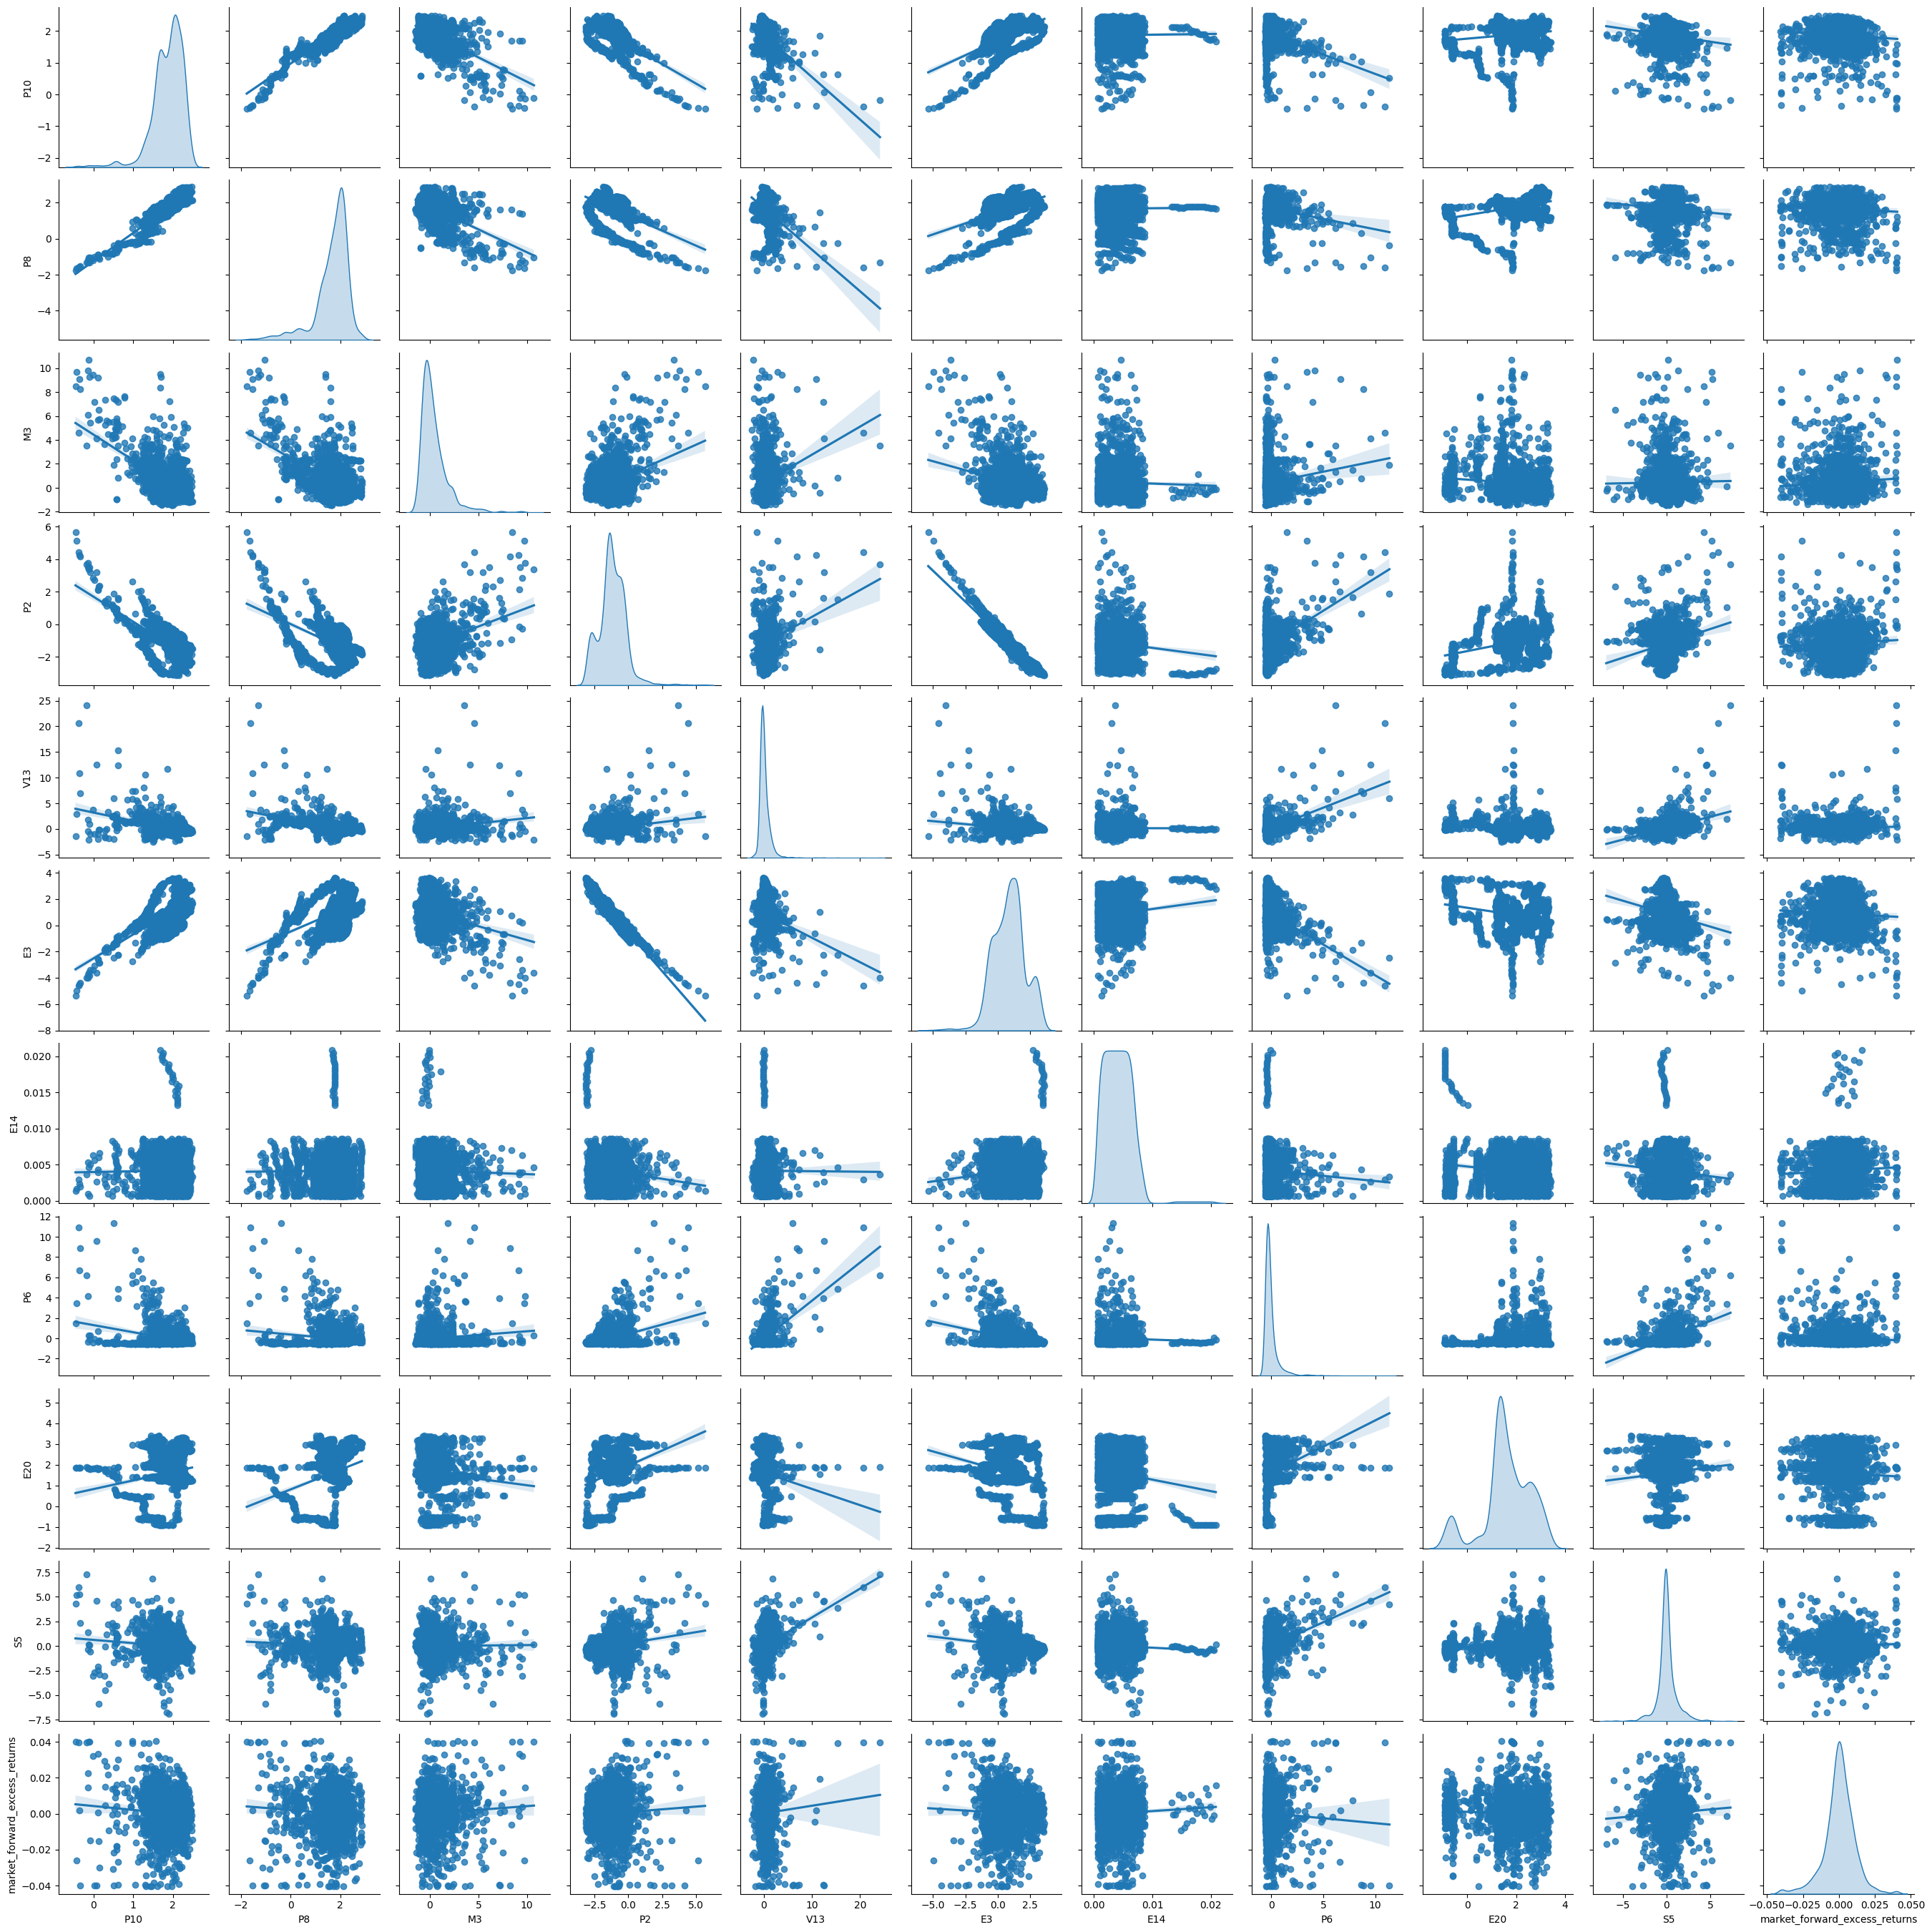

In [7]:
# Run pairplot on TOP 10 correlated features
top_features = corr_matrix[target].abs().sort_values(ascending=False).index[1:11]
sns.pairplot(df[list(top_features) + [target]], kind='reg', diag_kind='kde')
plt.show()

In [8]:
import numpy as np
import pandas as pd
import polars as pl
from scipy.optimize import minimize
from sklearn.preprocessing import StandardScaler
import os

# ============================================================
# 1. CONFIGURATION
# ============================================================
DATA_PATH = "/kaggle/input/hull-tactical-market-prediction"
LOOKBACK = 180        # optimization window
POSITION_BOUNDS = (0, 2)
INITIAL_WEIGHT = 1.0

# ============================================================
# 2. LOAD DATA
# ============================================================
def load_trainset():
    df = pl.read_csv(f"{DATA_PATH}/train.csv")
    df = df.rename({"market_forward_excess_returns": "target"})
    return df.with_columns(pl.exclude("date_id").cast(pl.Float64, strict=False))

def load_testset():
    df = pl.read_csv(f"{DATA_PATH}/test.csv")
    return df.with_columns(pl.exclude("date_id").cast(pl.Float64, strict=False))

# ============================================================
# 3. FEATURE SELECTION + SCALING
# ============================================================
def prepare_features(df: pl.DataFrame):
    features = [c for c in df.columns if c.startswith("D") or c.startswith("V")]
    df = df.drop_nulls(subset=["target"])
    scaler = StandardScaler()
    X = scaler.fit_transform(df.select(features).to_numpy())
    y = df["target"].to_numpy()
    return X, y, features, scaler

# ============================================================
# 4. ADJUSTED SHARPE OBJECTIVE
# ============================================================
def adjusted_sharpe_ratio(positions, returns, market_vol=0.012, max_vol_ratio=1.2):
    """Compute adjusted Sharpe ratio with penalties for high volatility."""
    portfolio_returns = positions * returns
    mean_ret = np.mean(portfolio_returns)
    vol = np.std(portfolio_returns)
    sharpe = mean_ret / (vol + 1e-8)

    # Volatility & underperformance penalties
    vol_penalty = 1.0 if vol <= max_vol_ratio * market_vol else (max_vol_ratio * market_vol) / vol
    ret_penalty = 1.0 if mean_ret >= 0 else 1.0 / (1.0 + np.abs(mean_ret))

    return -(sharpe * vol_penalty * ret_penalty)  # negative for minimization

# ============================================================
# 5. OPTIMISATION LOOP
# ============================================================
def optimize_positions(y, lookback=LOOKBACK):
    n = len(y)
    optimized_positions = np.zeros(n)

    for t in range(lookback, n):
        window = slice(t - lookback, t)
        returns_window = y[window]

        # minimize negative adjusted Sharpe
        res = minimize(
            adjusted_sharpe_ratio,
            x0=[INITIAL_WEIGHT],
            args=(returns_window,),
            method="Powell",
            bounds=[POSITION_BOUNDS],
            options={"disp": False}
        )

        optimized_positions[t] = np.clip(res.x[0], *POSITION_BOUNDS)

        if t % 500 == 0:
            print(f"Optimized up to day {t}/{n} | Position={optimized_positions[t]:.3f}")

    return optimized_positions

# ============================================================
# 6. MAIN PIPELINE
# ============================================================
def train_optimization_model():
    print("🔹 Loading full training data...")
    train = load_trainset()
    X, y, features, scaler = prepare_features(train)

    print("🔹 Running optimization-only tactical allocation...")
    positions = optimize_positions(y, lookback=LOOKBACK)

    print("✅ Optimization complete.")
    return positions, y

# ============================================================
# 7. EXECUTION
# ============================================================
positions, y = train_optimization_model()

# ============================================================
# 8. EVALUATION
# ============================================================
def adjusted_sharpe_summary(positions, y):
    portfolio_returns = positions * y
    mean_ret = np.mean(portfolio_returns)
    vol = np.std(portfolio_returns)
    sharpe = mean_ret / (vol + 1e-8)
    adj = -adjusted_sharpe_ratio(positions, y)
    print(f"\n📈 Mean return: {mean_ret:.6f}")
    print(f"📉 Volatility : {vol:.6f}")
    print(f"⚖️  Sharpe    : {sharpe:.3f}")
    print(f"✅ Adjusted   : {adj:.3f}")

adjusted_sharpe_summary(positions, y)


🔹 Loading full training data...
🔹 Running optimization-only tactical allocation...
Optimized up to day 500/9021 | Position=2.000
Optimized up to day 1000/9021 | Position=2.000
Optimized up to day 1500/9021 | Position=2.000
Optimized up to day 2000/9021 | Position=1.174
Optimized up to day 2500/9021 | Position=1.259
Optimized up to day 3000/9021 | Position=2.000
Optimized up to day 3500/9021 | Position=1.412
Optimized up to day 4000/9021 | Position=2.000
Optimized up to day 4500/9021 | Position=2.000
Optimized up to day 5000/9021 | Position=0.902
Optimized up to day 5500/9021 | Position=2.000
Optimized up to day 6000/9021 | Position=1.972
Optimized up to day 6500/9021 | Position=2.000
Optimized up to day 7000/9021 | Position=2.000
Optimized up to day 7500/9021 | Position=1.759
Optimized up to day 8000/9021 | Position=1.798
Optimized up to day 8500/9021 | Position=1.730
Optimized up to day 9000/9021 | Position=1.335
✅ Optimization complete.

📈 Mean return: 0.000094
📉 Volatility : 0.01931

In [9]:
import numpy as np
import polars as pl
from scipy.optimize import minimize
import kaggle_evaluation
import os

# ============================================================
# CONFIG
# ============================================================
LOOKBACK = 180
POSITION_BOUNDS = (0, 2)
INITIAL_WEIGHT = 1.0
DATA_PATH = "/kaggle/input/hull-tactical-market-prediction"

# ============================================================
# ADJUSTED SHARPE FUNCTION
# ============================================================
def adjusted_sharpe_ratio(positions, returns, market_vol=0.012, max_vol_ratio=1.2):
    portfolio_returns = positions * returns
    mean_ret = np.mean(portfolio_returns)
    vol = np.std(portfolio_returns)
    sharpe = mean_ret / (vol + 1e-8)
    vol_penalty = 1.0 if vol <= max_vol_ratio * market_vol else (max_vol_ratio * market_vol) / vol
    ret_penalty = 1.0 if mean_ret >= 0 else 1.0 / (1.0 + np.abs(mean_ret))
    return -(sharpe * vol_penalty * ret_penalty)

# ============================================================
# TRAINING / OPTIMIZATION
# ============================================================
def load_trainset():
    df = pl.read_csv(f"{DATA_PATH}/train.csv")
    df = df.rename({"market_forward_excess_returns": "target"})
    df = df.with_columns(pl.exclude("date_id").cast(pl.Float64, strict=False))
    return df.drop_nulls(subset=["target"])

train = load_trainset()
returns = train["target"].to_numpy()

def optimize_positions(y, lookback=LOOKBACK):
    n = len(y)
    optimized_positions = np.zeros(n)
    for t in range(lookback, n):
        window = slice(t - lookback, t)
        res = minimize(
            adjusted_sharpe_ratio,
            x0=[INITIAL_WEIGHT],
            args=(y[window],),
            method="Powell",
            bounds=[POSITION_BOUNDS],
            options={"disp": False}
        )
        optimized_positions[t] = np.clip(res.x[0], *POSITION_BOUNDS)
    return optimized_positions

print("🔹 Optimizing positions on full training data...")
positions = optimize_positions(returns)
print("✅ Optimization complete.")

# ============================================================
# PREDICT FUNCTION (for Kaggle API)
# ============================================================
def predict(test: pl.DataFrame) -> float:
    # Each test batch corresponds to one day; we ignore features and return static positions sequentially
    global positions
    # maintain internal counter
    if not hasattr(predict, "idx"):
        predict.idx = 0
    pos = float(np.clip(positions[min(predict.idx, len(positions) - 1)], 0, 2))
    predict.idx += 1
    return pos
    
import kaggle_evaluation.default_inference_server


# LAUNCH SERVER
# ============================================================
inference_server = kaggle_evaluation.default_inference_server.DefaultInferenceServer(predict)

if os.getenv("KAGGLE_IS_COMPETITION_RERUN"):
    inference_server.serve()
else:
    inference_server.run_local_gateway((DATA_PATH,))


🔹 Optimizing positions on full training data...
✅ Optimization complete.
